# Zomato India Restaurant Analysis: Exploratory Analysis
**Goal:** answer the business questions with data before building the Power BI dashboard.

**Business question:** what makes a restaurant on Zomato highly rated and popular, and how do location, cuisine, price and online delivery affect that?

1. Where are restaurants, and how do cities compare?
2. Which cuisines are most common, and which are rated highest?
3. Does a higher price mean a higher rating?
4. Do online delivery and table booking link to better ratings or more votes?
5. What do the top-rated, most-voted restaurants have in common?

**Input:** the cleaned files from `01_data_cleaning.ipynb`. Charts are saved to `images/` for the README.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('../data/processed/zomato_india_clean.csv')
cuisines = pd.read_csv('../data/processed/restaurant_cuisines.csv')

# rated restaurants only, for anything involving ratings
rated = df[df['is_rated'] == 1]
print(df.shape, rated.shape)

(8652, 18) (6513, 18)


### Chart style
One main color (blue), one highlight color (orange), grey for context. Light grid, no chart borders, values labelled directly.

In [2]:
BLUE, ORANGE, GREY = '#2a78d6', '#eb6834', '#b9b8b2'
TEXT, MUTED = '#0b0b0b', '#52514e'

plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#d6d5d0', 'axes.grid': True, 'grid.color': '#ecebe7',
    'axes.axisbelow': True, 'font.size': 10, 'axes.titlesize': 12,
    'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.labelcolor': MUTED, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'text.color': TEXT, 'figure.dpi': 110, 'savefig.dpi': 150,
    'savefig.bbox': 'tight'})

def save(fig, name):
    fig.savefig(f'../images/{name}.png')
    plt.show()

## 1. Where are the restaurants?

In [3]:
city = (df.groupby('city')
          .agg(restaurants=('restaurant_id', 'count'),
               avg_rating=('aggregate_rating', 'mean'),
               median_cost=('average_cost_for_two', 'median'))
          .sort_values('restaurants', ascending=False))
city.head(10)

,restaurants,avg_rating,median_cost
city,,,
New Delhi,5473,3.297381,400.0
Gurgaon,1118,3.330674,500.0
Noida,1080,3.159626,450.0
Faridabad,251,3.103311,400.0
Ghaziabad,25,3.100000,500.0
Ahmedabad,21,4.161905,900.0
Bhubaneshwar,21,3.980952,500.0
Amritsar,21,3.685714,500.0
Lucknow,21,4.195238,1000.0


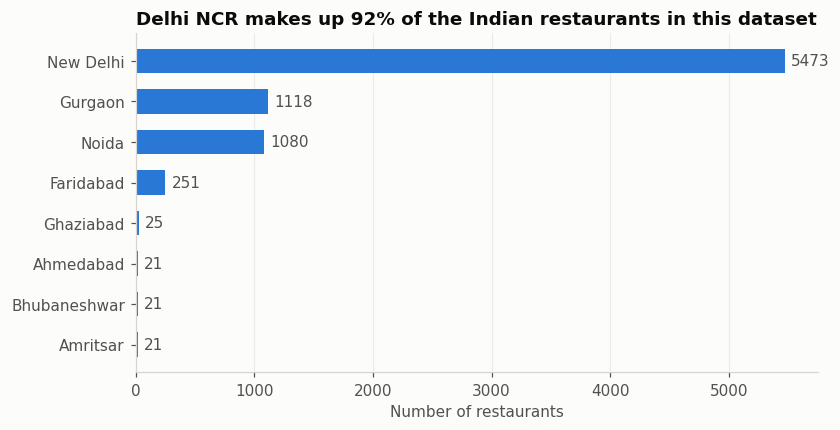

In [4]:
top = city.head(8)['restaurants'][::-1]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(top.index, top.values, color=BLUE, height=0.6)
ax.bar_label(bars, padding=4, color=MUTED)
ax.set_title('Delhi NCR makes up 92% of the Indian restaurants in this dataset')
ax.set_xlabel('Number of restaurants')
ax.grid(axis='y', visible=False)
save(fig, '01_restaurants_by_city')

Outside Delhi NCR, almost every city has exactly ~20 restaurants. Before comparing cities, let's check whether those 20 look like a random sample.

In [5]:
df.groupby('region').agg(restaurants=('restaurant_id', 'count'),
                         share_rated=('is_rated', 'mean'),
                         avg_rating=('aggregate_rating', 'mean'),
                         median_votes=('votes', 'median'),
                         median_cost=('average_cost_for_two', 'median')).round(2)

,restaurants,share_rated,avg_rating,median_votes,median_cost
region,,,,,
Delhi NCR,7947,0.73,3.28,19.0,450.0
Other cities,705,1.00,3.94,191.0,800.0


**Finding 1: the cities outside Delhi NCR are not a fair sample.**  
Every one of them is rated (100% vs 73% in Delhi NCR), they have a median of 191 votes vs 19, and they average 3.94 stars vs 3.28. Zomato appears to have included only ~20 popular restaurants per city. So "Bangalore rates higher than Delhi" would be a wrong conclusion. **City comparisons are only fair inside Delhi NCR.**

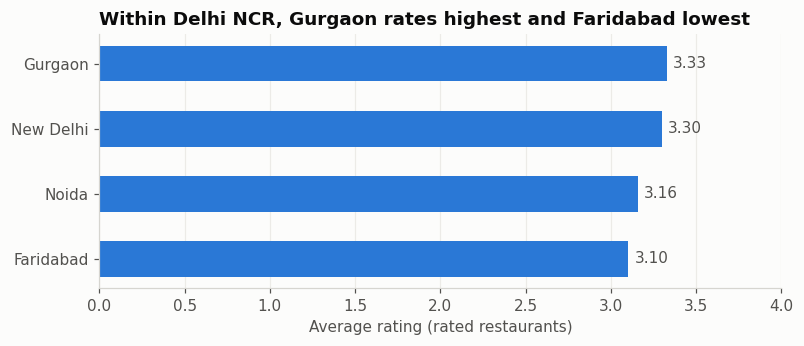

In [6]:
ncr_cities = ['New Delhi', 'Gurgaon', 'Noida', 'Faridabad']
ncr = city.loc[ncr_cities].sort_values('avg_rating')
fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(ncr.index, ncr['avg_rating'], color=BLUE, height=0.55)
ax.bar_label(bars, fmt='%.2f', padding=4, color=MUTED)
ax.set_xlim(0, 4)
ax.set_title('Within Delhi NCR, Gurgaon rates highest and Faridabad lowest')
ax.set_xlabel('Average rating (rated restaurants)')
ax.grid(axis='y', visible=False)
save(fig, '02_ncr_city_rating')

### Best-rated localities in Delhi NCR
Only localities with at least 30 rated restaurants, so a few lucky ratings can't top the list.

In [7]:
ncr_df = df[df['region'] == 'Delhi NCR']
loc = (ncr_df.groupby('locality')
             .agg(restaurants=('restaurant_id', 'count'),
                  rated=('aggregate_rating', 'count'),
                  avg_rating=('aggregate_rating', 'mean')))
best_loc = loc[loc['rated'] >= 30].sort_values('avg_rating', ascending=False).head(8)
best_loc.round(2)

,restaurants,rated,avg_rating
locality,,,
"Cyber Hub, DLF Cyber City",41,41,3.86
"DLF Mall of India, Sector 18, Noida",31,31,3.84
Sector 29,47,44,3.81
Khan Market,44,43,3.80
Connaught Place,122,119,3.78
Greater Kailash (GK) 1,66,66,3.70
Rajouri Garden,99,98,3.63
Vijay Nagar,31,31,3.61


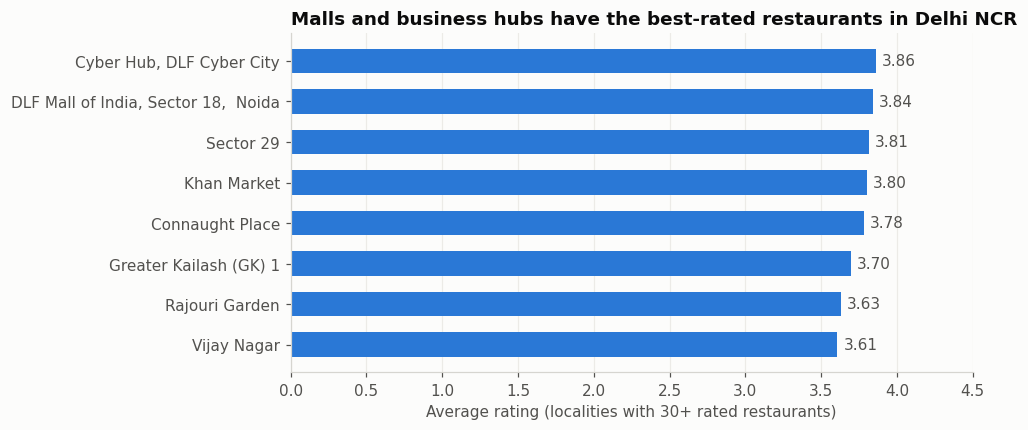

In [8]:
s = best_loc['avg_rating'][::-1]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(s.index, s.values, color=BLUE, height=0.6)
ax.bar_label(bars, fmt='%.2f', padding=4, color=MUTED)
ax.set_xlim(0, 4.5)
ax.set_title('Malls and business hubs have the best-rated restaurants in Delhi NCR')
ax.set_xlabel('Average rating (localities with 30+ rated restaurants)')
ax.grid(axis='y', visible=False)
save(fig, '03_top_ncr_localities')

**Finding 2:** the best-rated localities in Delhi NCR are malls and business hubs: Cyber Hub (3.86), DLF Mall of India (3.84), Sector 29 Gurgaon (3.81), Khan Market (3.80) and Connaught Place (3.78). The Delhi NCR average is 3.28.

## 2. Cuisines

In [9]:
cuisine_stats = cuisines.merge(df[['restaurant_id', 'aggregate_rating']], on='restaurant_id')
cuisine_summary = (cuisine_stats.groupby('cuisine')
                                .agg(restaurants=('restaurant_id', 'count'),
                                     rated=('aggregate_rating', 'count'),
                                     avg_rating=('aggregate_rating', 'mean')))
cuisine_summary.sort_values('restaurants', ascending=False).head(10)

,restaurants,rated,avg_rating
cuisine,,,
North Indian,3946,3003,3.291841
Chinese,2690,2139,3.268350
Fast Food,1963,1540,3.250065
Mughlai,992,791,3.267509
Bakery,726,517,3.366151
Continental,724,687,3.696798
Italian,682,644,3.707143
South Indian,631,480,3.232500
Cafe,627,559,3.625224


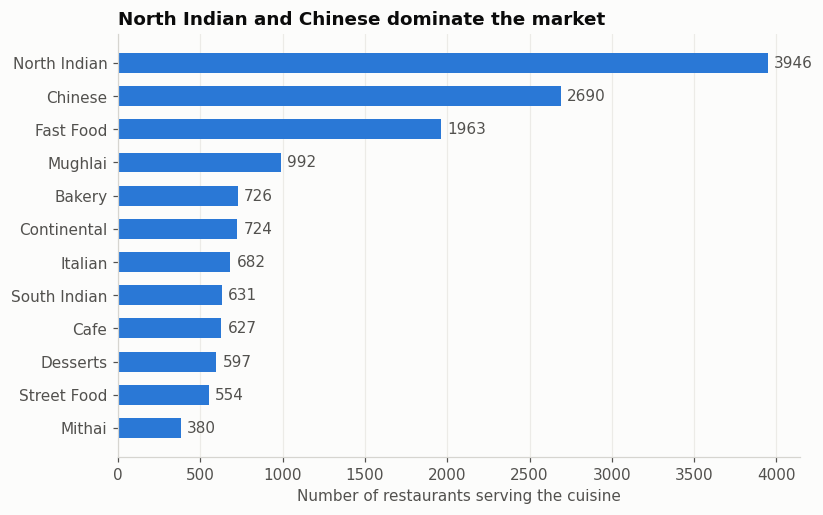

In [10]:
common = cuisine_summary['restaurants'].sort_values(ascending=False).head(12)[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(common.index, common.values, color=BLUE, height=0.6)
ax.bar_label(bars, padding=4, color=MUTED)
ax.set_title('North Indian and Chinese dominate the market')
ax.set_xlabel('Number of restaurants serving the cuisine')
ax.grid(axis='y', visible=False)
save(fig, '04_most_common_cuisines')

Ranking by average rating needs a minimum size, otherwise a cuisine with 3 restaurants could top the list. I use cuisines with at least 50 rated restaurants.

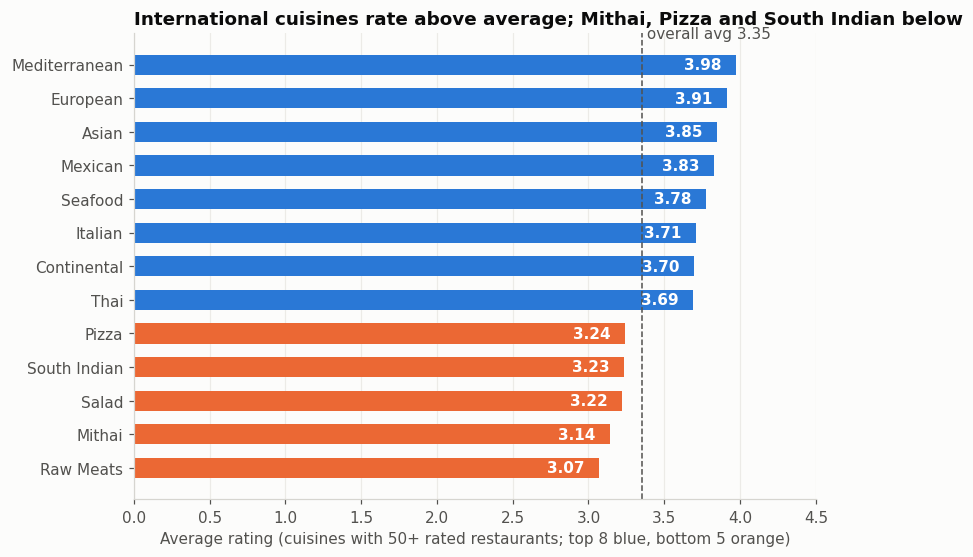

In [11]:
big = cuisine_summary[cuisine_summary['rated'] >= 50].sort_values('avg_rating')
overall = rated['aggregate_rating'].mean()
show = pd.concat([big.head(5), big.tail(8)])['avg_rating']

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = [ORANGE if v < overall else BLUE for v in show.values]
bars = ax.barh(show.index, show.values, color=colors, height=0.6)
ax.bar_label(bars, fmt='%.2f', label_type='edge', padding=-34, color='white', fontweight='bold')
ax.axvline(overall, color=MUTED, linewidth=1, linestyle='--')
ax.text(overall, len(show) - 0.3, f' overall avg {overall:.2f}', color=MUTED, va='bottom')
ax.set_xlim(0, 4.5)
ax.set_title('International cuisines rate above average; Mithai, Pizza and South Indian below')
ax.set_xlabel('Average rating (cuisines with 50+ rated restaurants; top 8 blue, bottom 5 orange)')
ax.grid(axis='y', visible=False)
save(fig, '05_cuisine_ratings')

**Finding 3:** the most common cuisines are North Indian (3,946 restaurants), Chinese (2,690) and Fast Food (1,963). The best-rated are Mediterranean (3.98), European (3.91), Asian (3.85) and Mexican (3.83). Raw Meats, Mithai, Salad, South Indian and Pizza rate lowest (3.07–3.24).

Note: international cuisines are usually more expensive, so part of this gap may come from price (see the next section), not from the cuisine itself.

## 3. Does a higher price mean a higher rating?

In [12]:
price = (df.groupby('price_range')
           .agg(restaurants=('restaurant_id', 'count'),
                share_rated=('is_rated', 'mean'),
                avg_rating=('aggregate_rating', 'mean'),
                median_cost=('average_cost_for_two', 'median')))
price.round(2)

,restaurants,share_rated,avg_rating,median_cost
price_range,,,,
1,4295,0.60,3.20,300.0
2,2858,0.86,3.31,600.0
3,1111,0.97,3.68,1200.0
4,388,0.97,3.73,2200.0


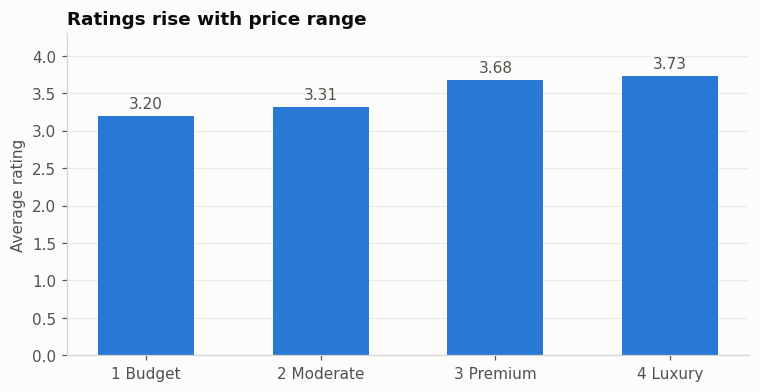

In [13]:
labels = ['1 Budget', '2 Moderate', '3 Premium', '4 Luxury']
fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.bar(labels, price['avg_rating'], color=BLUE, width=0.55)
ax.bar_label(bars, fmt='%.2f', padding=3, color=MUTED)
ax.set_ylim(0, 4.3)
ax.set_title('Ratings rise with price range')
ax.set_ylabel('Average rating')
ax.grid(axis='x', visible=False)
save(fig, '06_rating_by_price_range')

In [14]:
# Spearman correlation: works on ranks, so the 5-star outliers don't distort it
rated[['average_cost_for_two', 'aggregate_rating', 'votes']].corr(method='spearman').round(2)

,average_cost_for_two,aggregate_rating,votes
average_cost_for_two,1.00,0.33,0.50
aggregate_rating,0.33,1.00,0.65
votes,0.50,0.65,1.00


**Finding 4:** ratings rise steadily with price: 3.20 for budget restaurants, 3.73 for luxury. But the link is only moderate (Spearman correlation 0.33), so many cheap restaurants still rate well.

Budget restaurants are also much less likely to be rated at all (60% vs 97% for premium and luxury).

## 4. Online delivery and table booking

In [15]:
def compare(col):
    return (df.groupby(col)
              .agg(restaurants=('restaurant_id', 'count'),
                   share_rated=('is_rated', 'mean'),
                   avg_rating=('aggregate_rating', 'mean'),
                   median_votes=('votes', 'median'))
              .rename(index={0: 'No', 1: 'Yes'})
              .round(2))

compare('has_online_delivery')

,restaurants,share_rated,avg_rating,median_votes
has_online_delivery,,,,
No,6229,0.67,3.34,13.0
Yes,2423,0.96,3.37,77.0


In [16]:
# Is the rating difference real or just noise? Welch's t-test
yes = rated.loc[rated['has_online_delivery'] == 1, 'aggregate_rating']
no = rated.loc[rated['has_online_delivery'] == 0, 'aggregate_rating']
stats.ttest_ind(yes, no, equal_var=False)

TtestResult(statistic=np.float64(2.3655192938291827), pvalue=np.float64(0.018047848890560558), df=np.float64(4407.988952434415))

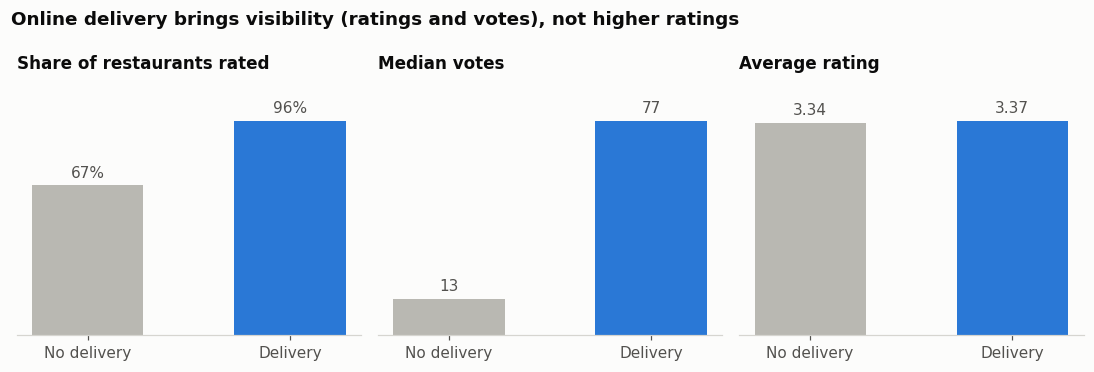

In [17]:
d = compare('has_online_delivery')
metrics = [('share_rated', 'Share of restaurants rated', '{:.0%}'),
           ('median_votes', 'Median votes', '{:.0f}'),
           ('avg_rating', 'Average rating', '{:.2f}')]

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
for ax, (col, title, fmt) in zip(axes, metrics):
    bars = ax.bar(['No delivery', 'Delivery'], d[col], color=[GREY, BLUE], width=0.55)
    ax.bar_label(bars, labels=[fmt.format(v) for v in d[col]], padding=3, color=MUTED)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, d[col].max() * 1.2)
    ax.set_yticks([])
    ax.grid(False)
    ax.spines['left'].set_visible(False)
fig.suptitle('Online delivery brings visibility (ratings and votes), not higher ratings',
             x=0.01, ha='left', fontweight='bold')
fig.tight_layout()
save(fig, '07_online_delivery')

**Finding 5: delivery is about visibility, not quality.**  
Restaurants with online delivery are much more likely to be rated (96% vs 67%) and get far more votes (median 77 vs 13). But their average rating is almost the same: 3.37 vs 3.34. The t-test says this 0.03 gap is statistically significant (p = 0.018), but it is far too small to matter in practice.

**Business meaning:** for a new restaurant, listing on delivery helps people find and review it. It won't, on its own, raise the rating.

In [18]:
compare('has_table_booking')

,restaurants,share_rated,avg_rating,median_votes
has_table_booking,,,,
No,7541,0.72,3.31,18.0
Yes,1111,0.96,3.55,145.0


In [19]:
# Table booking is mostly offered by expensive restaurants
pd.crosstab(df['price_range'], df['has_table_booking'], normalize='index').round(2)

has_table_booking,0,1
price_range,,
1,1.00,0.00
2,0.92,0.08
3,0.44,0.56
4,0.35,0.65


**Finding 6:** restaurants with table booking rate higher (3.55 vs 3.31), but table booking is mostly offered by premium and luxury restaurants (56% and 64% of them, vs under 1% of budget ones). So this difference is largely the price effect from section 3, not table booking itself. This is a **confounding variable**: always check for one before claiming that one thing causes another.

## 5. What do top restaurants have in common?

In [20]:
vote_band = pd.cut(rated['votes'], bins=[0, 10, 50, 200, 1000, np.inf],
                   labels=['Up to 10', '11-50', '51-200', '201-1000', '1000+'])
by_votes = rated.groupby(vote_band, observed=True)['aggregate_rating'].agg(['count', 'mean'])
by_votes.round(2)

,count,mean
votes,,
Up to 10,1051,2.96
11-50,2243,3.16
51-200,1973,3.44
201-1000,1011,3.82
1000+,235,4.11


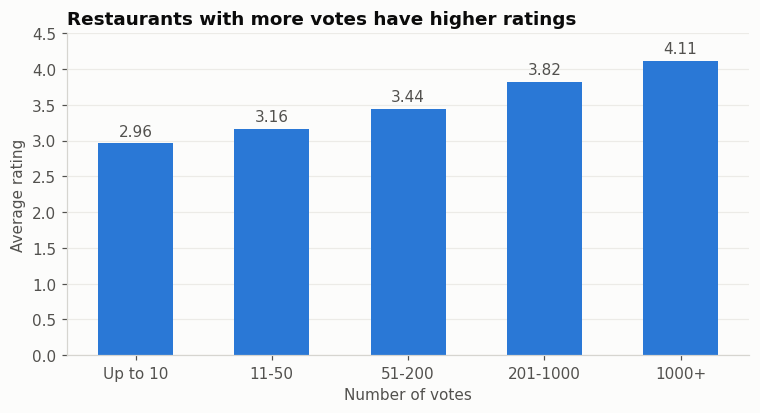

In [21]:
fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.bar(by_votes.index.astype(str), by_votes['mean'], color=BLUE, width=0.55)
ax.bar_label(bars, fmt='%.2f', padding=3, color=MUTED)
ax.set_ylim(0, 4.5)
ax.set_title('Restaurants with more votes have higher ratings')
ax.set_xlabel('Number of votes')
ax.set_ylabel('Average rating')
ax.grid(axis='x', visible=False)
save(fig, '08_rating_by_votes')

**Finding 7:** votes are the strongest link to rating in this data (Spearman 0.65). Restaurants with up to 10 votes average 2.96; those with over 1,000 votes average 4.11. Popular restaurants attract more diners and reviews, and well-rated restaurants become popular, so the effect works in both directions.

### Top 20 restaurants
Ranked by rating, then votes, with a minimum of 500 votes so a 4.9 with 3 votes can't win.

In [22]:
top20 = (rated[rated['votes'] >= 500]
         .sort_values(['aggregate_rating', 'votes'], ascending=False)
         .head(20)[['restaurant_name', 'city', 'locality', 'primary_cuisine',
                    'average_cost_for_two', 'aggregate_rating', 'votes', 'has_online_delivery']])
top20.reset_index(drop=True)

,restaurant_name,city,locality,primary_cuisine,average_cost_for_two,aggregate_rating,votes,has_online_delivery
0,Barbeque Nation,Kolkata,"Sector 5, Salt Lake",North Indian,1600.0,4.9,5966,0
1,AB's - Absolute Barbecues,Hyderabad,Jubilee Hills,European,1500.0,4.9,5434,0
2,Mirchi And Mime,Mumbai,Powai,North Indian,1500.0,4.9,3244,0
3,Naturals Ice Cream,New Delhi,Connaught Place,Ice Cream,150.0,4.9,2620,1
4,Indian Accent - The Manor,New Delhi,Friends Colony,Modern Indian,4000.0,4.9,1934,0
5,Barbeque Nation,Kolkata,Park Street Area,North Indian,1600.0,4.9,1753,0
6,Grandson of Tunday Kababi,Lucknow,Aminabad,Mughlai,300.0,4.9,1057,0
7,AB's - Absolute Barbecues,Chennai,Velachery,North Indian,1600.0,4.9,859,0
8,Barbeque Nation,Guwahati,Ulubari,North Indian,1500.0,4.9,774,0
9,Toit,Bangalore,Indiranagar,Italian,2000.0,4.8,10934,0


In [23]:
print('Median cost of top 20:', top20['average_cost_for_two'].median())
print('Median cost overall:', df['average_cost_for_two'].median())
print('Share outside Delhi NCR:', (~top20['city'].isin(ncr_cities + ['Ghaziabad'])).mean())
top20['restaurant_name'].value_counts().head(3)

Median cost of top 20: 1500.0
Median cost overall: 450.0
Share outside Delhi NCR: 0.8


restaurant_name
Barbeque Nation              3
AB's - Absolute Barbecues    2
Chili's                      2
Name: count, dtype: int64

**Finding 8:** the top 20 are mostly mid-to-premium dining places (median cost ₹1,500 for two vs ₹450 overall), and buffet and barbecue chains stand out: Barbeque Nation appears 3 times and AB's Absolute Barbecues twice. Most of the top 20 are outside Delhi NCR, which matches the sampling issue in Finding 1.

## Rating distribution

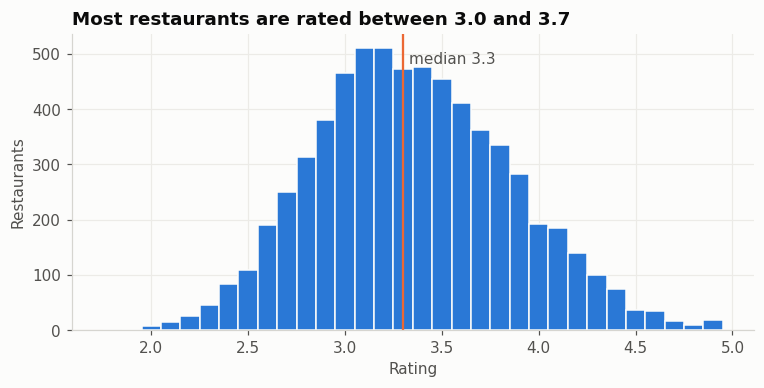

In [24]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(rated['aggregate_rating'], bins=np.arange(1.75, 5.0, 0.1), color=BLUE,
        edgecolor='#fcfcfb', linewidth=1)
ax.axvline(rated['aggregate_rating'].median(), color=ORANGE, linewidth=1.5)
ax.text(rated['aggregate_rating'].median() + 0.03, ax.get_ylim()[1] * 0.9,
        f"median {rated['aggregate_rating'].median():.1f}", color=MUTED)
ax.set_title('Most restaurants are rated between 3.0 and 3.7')
ax.set_xlabel('Rating')
ax.set_ylabel('Restaurants')
save(fig, '09_rating_distribution')

## Summary of findings
| # | Finding | Number |
|---|---|---|
| 1 | Outside Delhi NCR, only ~20 popular restaurants per city were included, so cross-city comparisons are biased | 100% rated vs 73%; 3.94 vs 3.28 |
| 2 | Malls and business hubs have Delhi NCR's best-rated restaurants | Cyber Hub 3.86, Khan Market 3.80 |
| 3 | North Indian and Chinese dominate; international cuisines rate highest | Mediterranean 3.98 vs Mithai 3.14 |
| 4 | Ratings rise with price, but only moderately | 3.20 budget → 3.73 luxury; ρ = 0.33 |
| 5 | Online delivery brings visibility, not higher ratings | 96% vs 67% rated; median votes 77 vs 13; rating 3.37 vs 3.34 |
| 6 | Table booking's higher rating is mostly a price effect | 3.55 vs 3.31, confounded by price |
| 7 | Votes are the strongest link to rating | ρ = 0.65; 2.96 → 4.11 |
| 8 | Top restaurants are mid-to-premium, often buffet/barbecue chains | Median ₹1,500 for two |

**Limitations:** a single snapshot (around 2019), uneven city coverage, and correlations only; none of these findings prove cause and effect.

**Next:** build the Power BI dashboard around these findings.